# Линейная регрессия: Демонстрация

В этом ноутбуке мы рассмотрим задачу линейной регрессии, используя:
1. **Аналитическое решение** (Closed-form solution)
2. **Градиентный спуск** (Iterative solution) с различными оптимизаторами из `optimizer_playground`
3. **Сравнение функций потерь** (MSE, MAE, Huber, LogCosh)
4. **Регуляризацию** (L1, L2, ElasticNet)

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from src.models import LinearRegression
from src.losses import MSE, MAE, Huber, LogCosh
from src.regularizers import L1, L2, Elastic_Net
from src.optimizers.gd import GD
from src.optimizers.momentum import Momentum, NesterovMomentum
from src.optimizers.rmsprop import RMSProp
from src.optimizers.adam import Adam
from src.optimizers.adamw import AdamW

%matplotlib inline


## 1. Подготовка данных

Сгенерируем синтетический датасет для регрессии.
Разделим данные на Train, Validation и Test, чтобы корректно подбирать гиперпараметры.

In [12]:
X, y = make_regression(n_samples=500, n_features=5, noise=15, random_state=42)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train_scaled.shape[0]} samples")
print(f"Validation set: {X_val_scaled.shape[0]} samples")
print(f"Test set: {X_test_scaled.shape[0]} samples")
print(f"Features: {X_train_scaled.shape[1]}")

Training set: 350 samples
Validation set: 75 samples
Test set: 75 samples
Features: 5


### Визуализация данных (первые 2 признака)

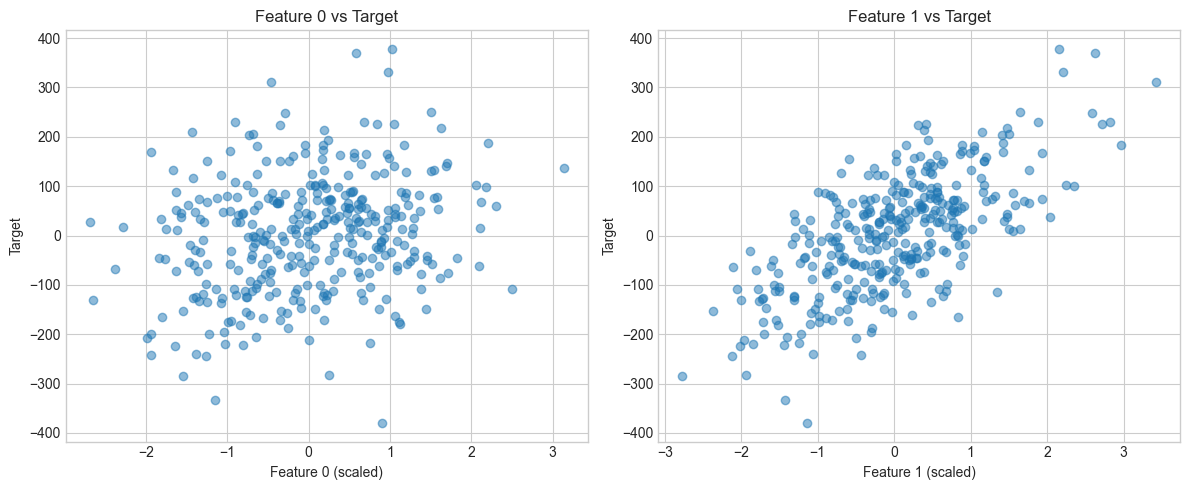

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_train_scaled[:, 0], y_train, alpha=0.5)
axes[0].set_title("Feature 0 vs Target")
axes[0].set_xlabel("Feature 0 (scaled)")
axes[0].set_ylabel("Target")

axes[1].scatter(X_train_scaled[:, 1], y_train, alpha=0.5)
axes[1].set_title("Feature 1 vs Target")
axes[1].set_xlabel("Feature 1 (scaled)")
axes[1].set_ylabel("Target")

plt.tight_layout()
plt.show()

## 2. Сравнение Closed-Form vs Iterative (GD)

Сравним аналитическое решение (Normal Equation) и градиентный спуск.

In [14]:
model_closed = LinearRegression(solver="closed")
model_closed.fit(X_train_scaled, y_train)
y_pred_closed = model_closed.predict(X_test_scaled)
mse_closed = mean_squared_error(y_test, y_pred_closed)
r2_closed = r2_score(y_test, y_pred_closed)

model_gd = LinearRegression(solver="iterative", opt=GD(lr=0.1), steps=1000)
model_gd.fit(X_train_scaled, y_train)
y_pred_gd = model_gd.predict(X_test_scaled)
mse_gd = mean_squared_error(y_test, y_pred_gd)
r2_gd = r2_score(y_test, y_pred_gd)

print(f"Closed Form: MSE={mse_closed:.4f}, R2={r2_closed:.4f}")
print(f"Gradient Descent: MSE={mse_gd:.4f}, R2={r2_gd:.4f}")

Closed Form: MSE=214.5792, R2=0.9821
Gradient Descent: MSE=214.5792, R2=0.9821


## 3. Визуализация сходимости оптимизаторов

В этом разделе мы сравним различные оптимизаторы.

### 3.1. "Наивное" сравнение (фиксированный LR)

Сначала посмотрим, как ведут себя оптимизаторы при одинаковом (фиксированном) learning rate. Это демонстрирует чувствительность разных методов к выбору LR.

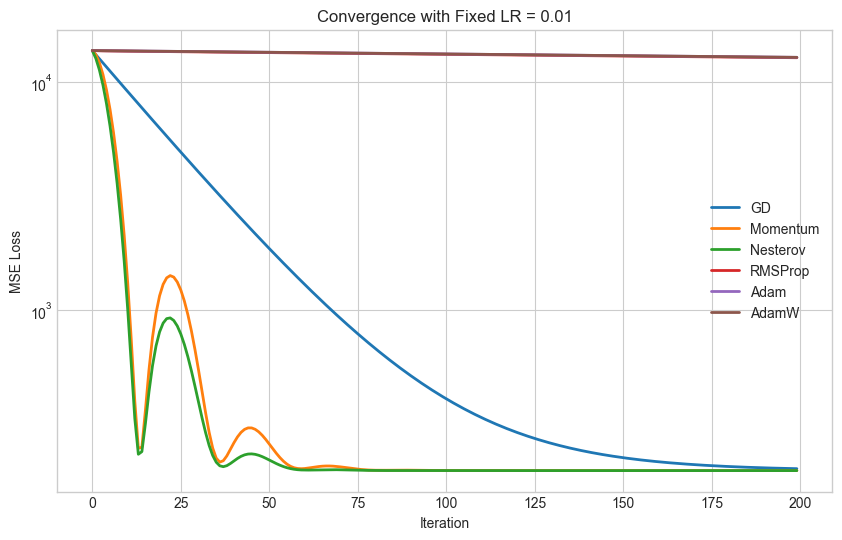

In [15]:
optimizers = {
    "GD": GD(lr=0.01),
    "Momentum": Momentum(lr=0.01, momentum=0.9),
    "Nesterov": NesterovMomentum(lr=0.01, momentum=0.9),
    "RMSProp": RMSProp(lr=0.01),
    "Adam": Adam(lr=0.01),
    "AdamW": AdamW(lr=0.01)
}

history_dict = {}

fig, ax = plt.subplots(figsize=(10, 6))

for name, opt in optimizers.items():
    model = LinearRegression(
        solver="iterative", opt=opt, loss=MSE(), steps=200, random_state=42
    )
    model.fit(X_train_scaled, y_train)
    history_dict[name] = model.history
    
    if model.history:
        ax.plot(model.history, label=name, linewidth=2)

ax.set_title("Convergence with Fixed LR = 0.01")
ax.set_xlabel("Iteration")
ax.set_ylabel("MSE Loss")
ax.set_yscale("log")
ax.legend()
plt.show()

### 3.2. Подбор гиперпараметров (Tuning)

Теперь подберем оптимальный `learning_rate` для каждого оптимизатора, используя **Validation** выборку. Это позволит сравнить их "честную" производительность.

In [16]:
optimizers_factories = {
    "GD": lambda lr: GD(lr=lr),
    "Momentum": lambda lr: Momentum(lr=lr, momentum=0.9),
    "Nesterov": lambda lr: NesterovMomentum(lr=lr, momentum=0.9),
    "RMSProp": lambda lr: RMSProp(lr=lr, beta=0.9),
    "Adam": lambda lr: Adam(lr=lr, beta_2=0.99),
    "AdamW": lambda lr: AdamW(lr=lr, beta_2=0.99, weight_decay=0.001),
}

lrs_grid = [1e-4, 1e-3, 1e-2, 0.1, 0.5, 1.0]
tuned_results = {}

print(f"{'Optimizer':<15} {'Best LR':<10} {'Val MSE':<12} {'Test MSE':<12}")
print("-" * 55)

for name, factory in optimizers_factories.items():
    best_val_mse = float("inf")
    best_lr = None
    best_model = None

    for lr in lrs_grid:
        opt = factory(lr)
        model = LinearRegression(
            solver="iterative", opt=opt, loss=MSE(), steps=200, random_state=42
        )
        model.fit(X_train_scaled, y_train)
        
        y_val_pred = model.predict(X_val_scaled)
        val_mse = mean_squared_error(y_val, y_val_pred)
        
        if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_lr = lr
            best_model = model

    y_test_pred = best_model.predict(X_test_scaled)
    test_mse = mean_squared_error(y_test, y_test_pred)
    
    tuned_results[name] = {
        "best_lr": best_lr,
        "val_mse": best_val_mse,
        "test_mse": test_mse,
        "history": best_model.history
    }
    
    print(f"{name:<15} {best_lr:<10} {best_val_mse:>12.4f} {test_mse:>12.4f}")

Optimizer       Best LR    Val MSE      Test MSE    
-------------------------------------------------------
GD              0.01           248.5812     222.6018
Momentum        0.001          249.9753     216.7117
Nesterov        0.001          249.7778     217.1341
RMSProp         1.0            246.6371     221.6413
Adam            1.0            251.0453     214.5174
AdamW           1.0            247.4149     223.2600


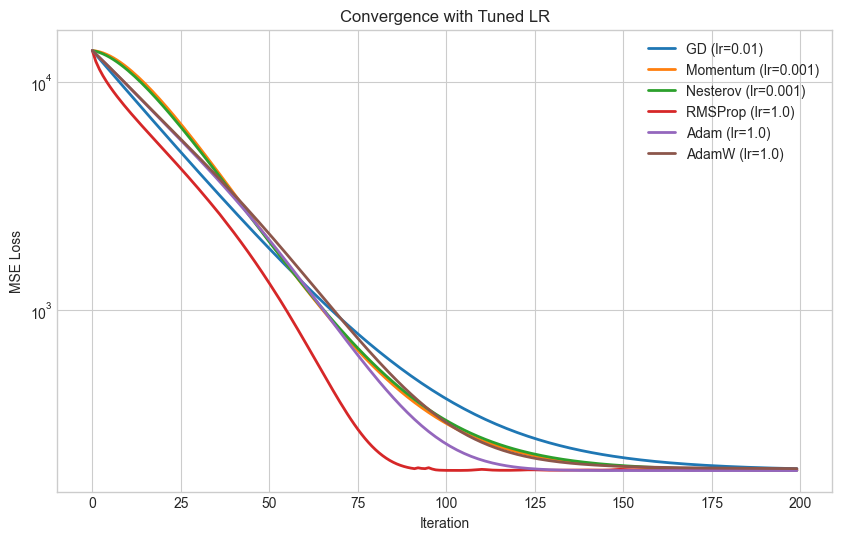

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

for name, res in tuned_results.items():
    ax.plot(res["history"], label=f"{name} (lr={res['best_lr']})", linewidth=2)

ax.set_title("Convergence with Tuned LR")
ax.set_xlabel("Iteration")
ax.set_ylabel("MSE Loss")
ax.set_yscale("log")
ax.legend()
plt.show()

## 4. Сравнение функций потерь

Сравним, как модель обучается с разными Loss Functions (MSE, MAE, Huber, LogCosh).
Для честного сравнения мы будем использовать **один и тот же оптимизатор (Adam)** и фиксированный **Learning Rate**.
Качество будем оценивать по метрике **MSE на валидационном наборе**, так как значения самих функций потерь находятся в разных масштабах и их нельзя сравнивать напрямую.

Training with 500 steps, lr=0.1...


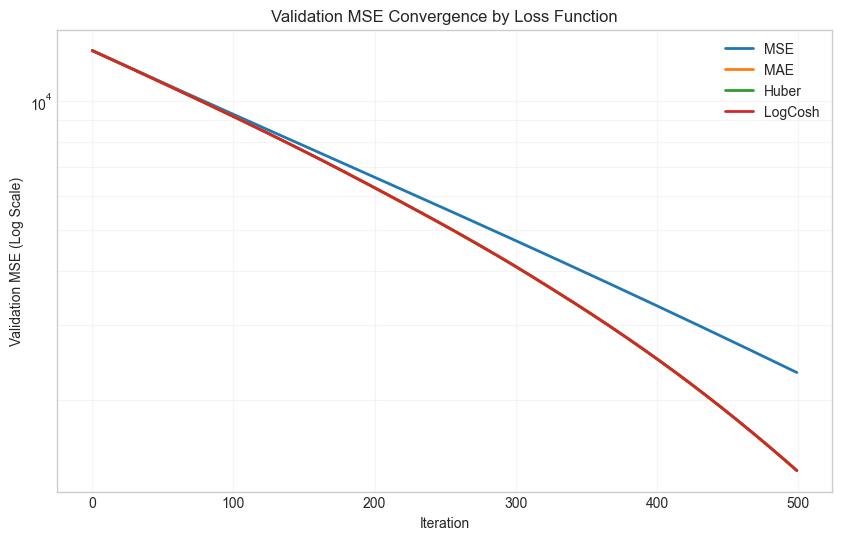

In [18]:
losses = {
    "MSE": MSE(),
    "MAE": MAE(),
    "Huber": Huber(delta=1.0),
    "LogCosh": LogCosh()
}

val_mse_histories = {}

X_train_b = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_val_b = np.c_[np.ones((X_val_scaled.shape[0], 1)), X_val_scaled]

n_steps = 500
fixed_lr = 0.1

print(f"Training with {n_steps} steps, lr={fixed_lr}...")

for name, loss_fn in losses.items():
    optimizer = Adam(lr=fixed_lr)
    rng = np.random.default_rng(42)
    w = rng.standard_normal(X_train_b.shape[1]) * 0.01
    
    history = []
    
    for _ in range(n_steps):
        grad = loss_fn.gradient(X_train_b, w, y_train)
        w = optimizer.step(w, grad)
        
        val_pred = X_val_b @ w
        val_mse = mean_squared_error(y_val, val_pred)
        history.append(val_mse)
        
    val_mse_histories[name] = history

fig, ax = plt.subplots(figsize=(10, 6))
for name, history in val_mse_histories.items():
    ax.plot(history, label=name, linewidth=2)

ax.set_title("Validation MSE Convergence by Loss Function")
ax.set_xlabel("Iteration")
ax.set_ylabel("Validation MSE (Log Scale)")
ax.set_yscale("log")
ax.legend()
ax.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

## 5. Влияние регуляризации

Исследуем L1, L2 и ElasticNet регуляризацию. Подберем коэффициент регуляризации `alpha` по валидационной выборке.

In [19]:
alpha_grid = [0.0, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0]

reg_configs = {
    "Lasso (L1)": (L1, {}),
    "Ridge (L2)": (L2, {}),
    "ElasticNet": (Elastic_Net, {"l1_ratio": 0.5})
}

results_data = []
best_weights = {}

print("Training regularized models...")

for name, (reg_cls, kwargs) in reg_configs.items():
    best_mse_val = float("inf")
    best_alpha = None
    best_model = None
    
    for alpha in alpha_grid:
        if alpha == 0:
            reg = None
        else:
            reg = reg_cls(alpha=alpha, **kwargs)
            
        model = LinearRegression(
            solver="iterative",
            opt=Adam(lr=0.01),
            reg=reg,
            steps=2000,
            random_state=42,
            loss_smoothing=1.0
        )
        
        model.fit(X_train_scaled, y_train)
        
        val_pred = model.predict(X_val_scaled)
        mse_val = mean_squared_error(y_val, val_pred)
        
        if mse_val < best_mse_val:
            best_mse_val = mse_val
            best_alpha = alpha
            best_model = model
            
    pred_test = best_model.predict(X_test_scaled)
    test_mse = mean_squared_error(y_test, pred_test)
    test_r2 = r2_score(y_test, pred_test)
    
    w_weights = best_model.w[1:] if best_model.fit_intercept else best_model.w
    sparsity = np.sum(np.abs(w_weights) < 1e-3)
    
    best_weights[name] = w_weights
    
    results_data.append({
        "Model": name,
        "Best Alpha": best_alpha,
        "Val MSE": best_mse_val,
        "Test MSE": test_mse,
        "Test R2": test_r2,
        "Sparsity": sparsity
    })

df_res = pd.DataFrame(results_data)
display(df_res.style.background_gradient(cmap="Blues", subset=["Test R2"])\
             .format({"Val MSE": "{:.4f}", "Test MSE": "{:.4f}", "Test R2": "{:.4f}"}))

Training regularized models...


,Model,Best Alpha,Val MSE,Test MSE,Test R2,Sparsity
0,Lasso (L1),0.000000,6631.4408,6705.1436,0.4410,0
1,Ridge (L2),0.000000,6631.4408,6705.1436,0.4410,0
2,ElasticNet,0.000000,6631.4408,6705.1436,0.4410,0


### Сравнение весов (Sparsity)

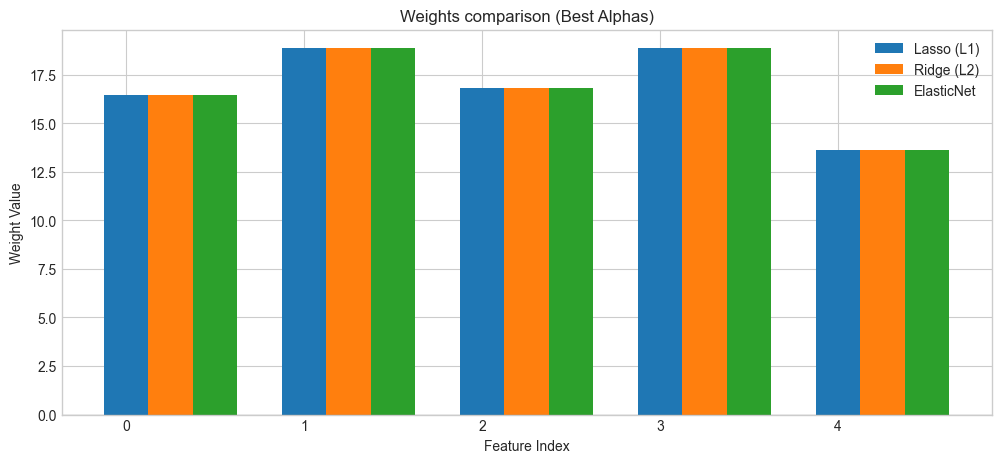

In [20]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(best_weights["Lasso (L1)"]))
width = 0.25

for i, (name, w) in enumerate(best_weights.items()):
    ax.bar(x + i*width, w, width, label=f"{name}")

ax.axhline(0, color='black', linewidth=0.8)
ax.set_title("Weights comparison (Best Alphas)")
ax.set_xlabel("Feature Index")
ax.set_ylabel("Weight Value")
ax.legend()
plt.show()

## Выводы

1. **Чувствительность к learning rate:** Диапазон рабочих `lr` отличается между оптимизаторами; подбор по **Val** критичен для корректных сравнений.
2. **Сходимость:** На выпуклой задаче (линейная регрессия + MSE) при адекватных настройках все оптимизаторы достигают сопоставимого минимума, различаясь скоростью и стабильностью.
3. **Робастность к выбросам:** Робастные лоссы уменьшают влияние выбросов и делают оценку тренда устойчивее.
4. **Регуляризация:** L2 стабилизирует веса и снижает риск переобучения; L1/ElasticNet могут выполнять отбор признаков при достаточно сильной регуляризации.
